# Tree based models

In [10]:

%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parents[1]))  # workaround to resolve my helper module above

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from xgboost import XGBRegressor, XGBRFRegressor
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold, cross_val_score, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np
import pickle

from skopt import BayesSearchCV
from skopt.space import Real, Integer

from modules.plotting import *

DATA_PATH = "./data/"
MODELS_PATH = "./models/"
SUBMISSIONS_PATH = "./submissions/"
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
training_data = pl.read_csv(DATA_PATH + "label_encoded_feat_eng.csv")
test_data = pl.read_csv(DATA_PATH + "test.csv")

In [4]:
X = training_data.drop("quality_score")
y = training_data["quality_score"]

## Baseline XGB

In [5]:
baseline_xgb = XGBRegressor(random_state=RANDOM_SEED)

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error"
}

cv_baseline_xgb_res = cross_validate(baseline_xgb, X, y, cv=kfold, scoring=scoring, n_jobs=-1, return_estimator=True)

rmse_scores_baseline = -cv_baseline_xgb_res["test_rmse"]
r2_scores_baseline = cv_baseline_xgb_res["test_r2"]

print("Average R²:", r2_scores_baseline.mean())
print("Average RMSE:", rmse_scores_baseline.mean())

Average R²: 0.1323547124862671
Average RMSE: 0.10842301100492477


## Baseline XGBRF

In [6]:
baseline_xgbrf = XGBRFRegressor(random_state=RANDOM_SEED)

cv_baseline_xgbrf_res = cross_validate(baseline_xgbrf, X, y, cv=kfold, scoring=scoring, n_jobs=-1, return_estimator=True)

rmse_scores_baseline = -cv_baseline_xgbrf_res["test_rmse"]
r2_scores_baseline = cv_baseline_xgbrf_res["test_r2"]

print("Average R²:", r2_scores_baseline.mean())
print("Average RMSE:", rmse_scores_baseline.mean())

Average R²: 0.24277933835983276
Average RMSE: 0.1013413354754448


## Tuning XGBRegressor

In [7]:
search_space = {
    "n_estimators": (50, 500),
    "learning_rate": (0.01, 0.3, "log-uniform"),
    "max_depth": (3, 10),
    "min_child_weight": (1, 10),
    "subsample": (0.5, 1.0, "uniform"),
    "colsample_bytree": (0.5, 1.0, "uniform"),
    "gamma": (0, 5.0),
    "reg_alpha": (0.0, 1.0),
    "reg_lambda": (0.0, 1.0)
}

In [8]:
tuning_xgb = XGBRegressor(objective="reg:squarederror", random_state=RANDOM_SEED, n_jobs=-1)

# Set up Bayesian optimization
opt = BayesSearchCV(
    estimator=tuning_xgb,
    search_spaces=search_space,
    scoring="neg_root_mean_squared_error",
    n_iter=50,
    cv=kfold,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbose=0
)

opt.fit(X, y)


BayesSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
              estimator=XGBRegressor(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     imp...
                                     n_jobs=-1, num_parallel_tree=None, ...),
              n_jobs=-1, random_state=42, scoring='neg_root_mean_squared_error',
              search_spaces={'colsample_bytree': (0.5, 1.0, 'uniform'),
                             'gamma': (0, 5.0),
                             'learning_rate': (0.01, 0.3, 'log-uniform'),
                             'max_depth': (3, 10), 'min_child_weight': (1, 10),
                             'n_estimators': (50, 500), 'reg_alpha': (0.0, 1.0),
                             'reg_lambda': (0.0, 1.0),
                             'subsample': (0.5, 1.0, 'uniform')})

In [9]:

print("Best RMSE:", -opt.best_score_)
print("Best Params:", opt.best_params_)

Best RMSE: 0.09916829615831375
Best Params: OrderedDict({'colsample_bytree': 0.5043386676752993, 'gamma': 0.04011172908352512, 'learning_rate': 0.03815496031143225, 'max_depth': 4, 'min_child_weight': 9, 'n_estimators': 481, 'reg_alpha': 0.9586691778557089, 'reg_lambda': 0.8201014166542614, 'subsample': 0.6409096339823396})


## Tuning XGBRF

In [14]:
search_space_xgbrf = {
    "n_estimators": Integer(50, 500),
    "max_depth": Integer(3, 15),
    "min_child_weight": Integer(1, 10),
    "subsample": Real(0.5, 1.0),           # row sampling
    "colsample_bynode": Real(0.3, 1.0),    # column sampling per split
    "reg_alpha": Real(1e-5, 10.0, prior="log-uniform"),
    "reg_lambda": Real(1e-5, 10.0, prior="log-uniform"),
}

In [15]:
tuning_xgbrf = XGBRFRegressor(objective="reg:squarederror", random_state=RANDOM_SEED, n_jobs=-1)

# Set up Bayesian optimization
opt_xgbrf = BayesSearchCV(
    estimator=tuning_xgbrf,
    search_spaces=search_space_xgbrf,
    scoring="neg_root_mean_squared_error",
    n_iter=50,
    cv=kfold,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbose=0
)

opt_xgbrf.fit(X, y)

BayesSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
              estimator=XGBRFRegressor(base_score=None, booster=None,
                                       callbacks=None, colsample_bylevel=None,
                                       colsample_bytree=None, device=None,
                                       early_stopping_rounds=None,
                                       enable_categorical=False,
                                       eval_metric=None, feature_types=None,
                                       feature_weights=None, gamma=None,
                                       grow_policy=None, importance_type=None,
                                       in...
                             'min_child_weight': Integer(low=1, high=10, prior='uniform', transform='normalize'),
                             'n_estimators': Integer(low=50, high=500, prior='uniform', transform='normalize'),
                             'reg_alpha': Real(low=1e-05, high=10.0, prior='log-uniform', transform='normalize'),
                             'reg_lambda': Real(low=1e-05, high=10.0, prior='log-uniform', transform='normalize'),
                             'subsample': Real(low=0.5, high=1.0, prior='uniform', transform='normalize')})

In [16]:
print("Best RMSE:", -opt_xgbrf.best_score_)
print("Best Params:", opt_xgbrf.best_params_)

Best RMSE: 0.09973126053810119
Best Params: OrderedDict({'colsample_bynode': 0.4356179825586185, 'max_depth': 9, 'min_child_weight': 3, 'n_estimators': 308, 'reg_alpha': 1e-05, 'reg_lambda': 1e-05, 'subsample': 0.5})


### Submission with opt_xgbrf

In [45]:
def preprocessing_for_test_with_all_data(test: pl.DataFrame) -> pl.DataFrame:
    prods = test.with_columns(
        pl.col("production_time").str.extract(r"^(\d{2})", 1).cast(pl.Int8).alias("hour")
    )

    prods = prods.with_columns([
        pl.col("production_date").str.strptime(pl.Date, "%Y-%m-%d")
    ])

    prods = prods.with_columns([
        pl.col("production_date").dt.month().alias("month"),
        pl.col("production_date").dt.day().alias("day")
    ])

    prods = prods.drop("production_date", "production_time", "id")

    test_for_eng = prods.with_columns(
        (pl.col("total_luminosity") - pl.col("min_luminosity")).alias("delta_luminosity")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("plate_thickness") * pl.col("plate_length")).alias("volume_proxy")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("volume_proxy") / pl.col("processing_time")).alias("processing_efficiency")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("defect_area") / pl.col("volume_proxy")).alias("defect_proportion")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("square_index") * pl.col("edge_index")).alias("geometry_score")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("temperature") / pl.col("cooling_rate")).alias("cooling_difficulty")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("brightness_index") * pl.col("volume_proxy")).alias("brightness_times_volume")
    )

    label_encoded_test = test_for_eng.with_columns(
        pl.col("machine_id").cast(pl.Categorical).to_physical()
    )

    return label_encoded_test

In [47]:
test_all_data = preprocessing_for_test_with_all_data(test_data)

best_xgbrf_all_data = opt_xgbrf.best_estimator_

best_xgbrf_all_data.fit(X, y)

y_pred_all_data = best_xgbrf_all_data.predict(test_all_data)

preds_final_xgbrf_all = pl.DataFrame(
    pl.Series("quality_score", y_pred_all_data)
).with_row_index("id")

preds_final_xgbrf_all.write_csv(SUBMISSIONS_PATH + "xgbrf_all_data.csv")

## Trying to Drop some Features

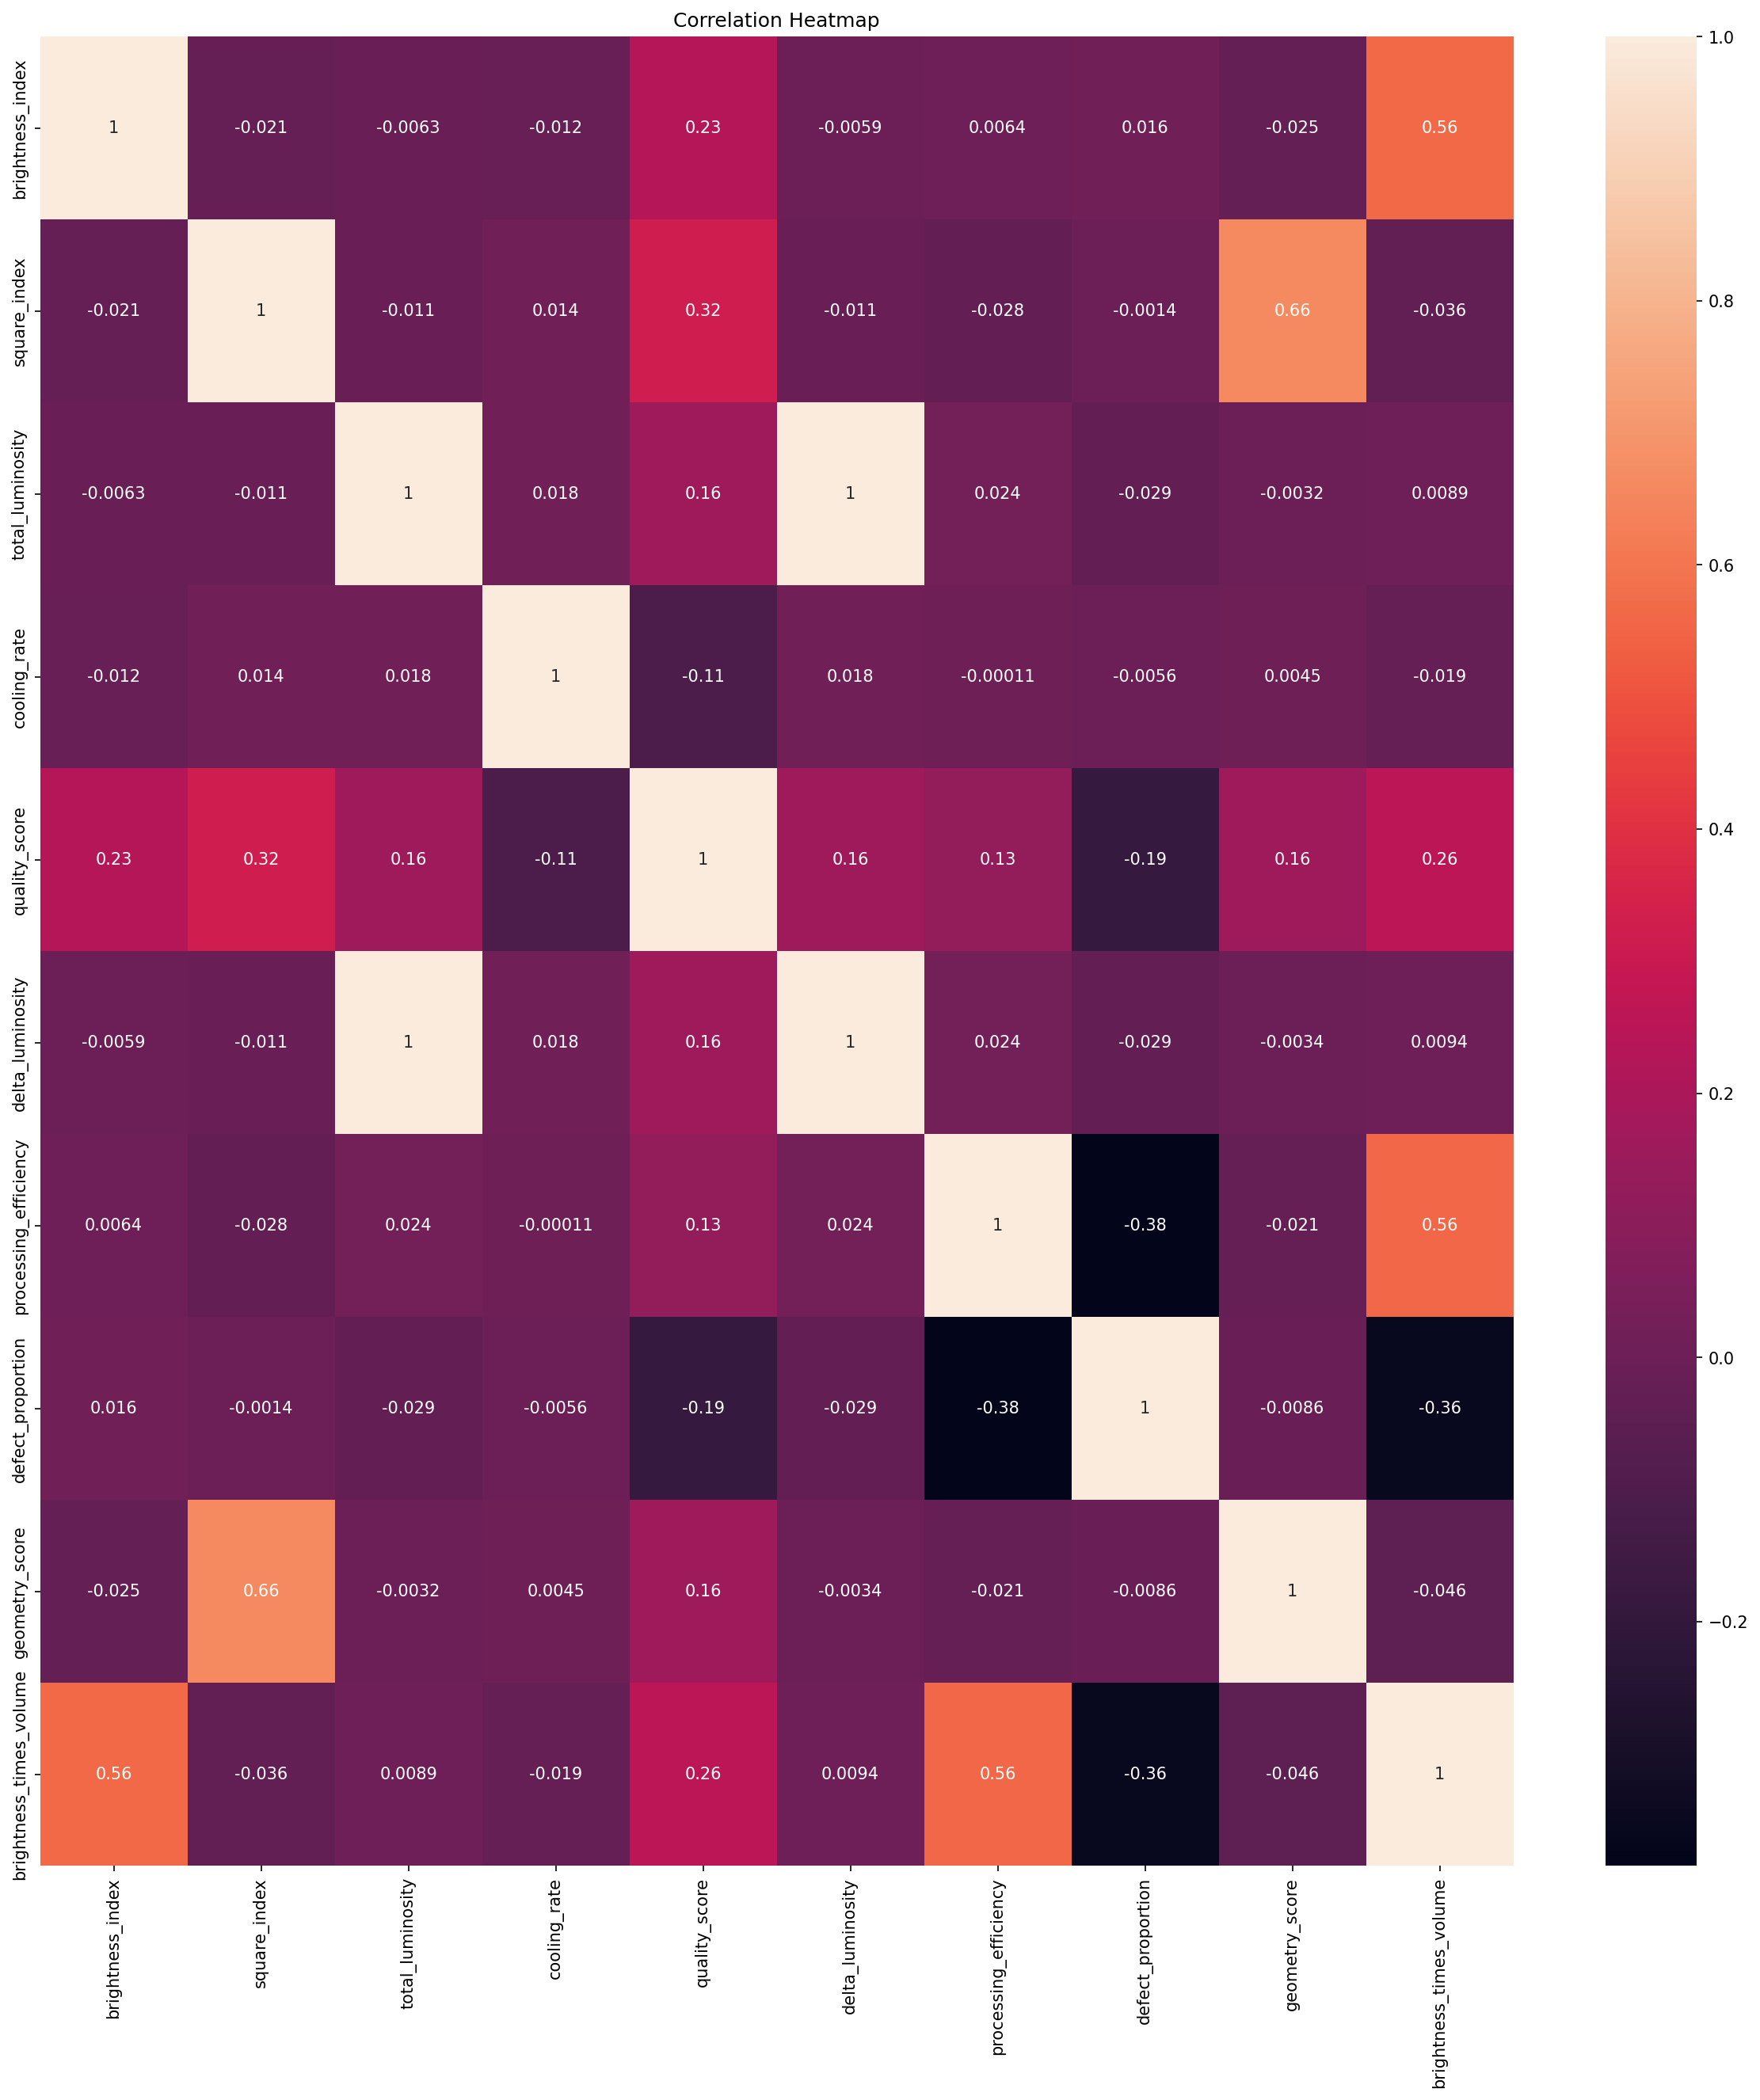

In [19]:
dropped_feats = training_data.drop(
    "volume_proxy", 
    "plate_length", 
    "min_luminosity", 
    "defect_area", 
    "edge_index", 
    "processing_time", 
    "temperature",
    "cooling_difficulty",
    "plate_thickness"
)

dropped_corr = dropped_feats.drop("day", "month", "hour", "machine_id", "operator_id").to_pandas().corr()

plt.figure(figsize=(20, 20))

sns.heatmap(
    dropped_corr,
    annot=True
)
plt.title("Correlation Heatmap")
plt.show()

In [20]:
dropped_feats.schema

Schema([('brightness_index', Float64),
        ('square_index', Float64),
        ('total_luminosity', Float64),
        ('cooling_rate', Float64),
        ('quality_score', Float64),
        ('operator_id', Int64),
        ('machine_id', Int64),
        ('hour', Int64),
        ('month', Int64),
        ('day', Int64),
        ('delta_luminosity', Float64),
        ('processing_efficiency', Float64),
        ('defect_proportion', Float64),
        ('geometry_score', Float64),
        ('brightness_times_volume', Float64)])

In [21]:
X_dropped = dropped_feats.drop("quality_score")
y_dropped = dropped_feats["quality_score"]

In [24]:
def quick_prototyping_xgb(X, y):
    xgb = XGBRegressor(random_state=RANDOM_SEED)

    cv_xgb = cross_validate(xgb, X, y, cv=kfold, scoring=scoring, n_jobs=-1, return_estimator=True)

    rmse_scores = -cv_xgb["test_rmse"]
    r2_scores = cv_xgb["test_r2"]

    print("Average R²:", rmse_scores.mean())
    print("Average RMSE:", r2_scores.mean())

In [25]:
quick_prototyping_xgb(X_dropped, y_dropped)

Average R²: 0.1108123242855072
Average RMSE: 0.09397815465927124


In [26]:
X_dropped2 = X_dropped.drop("operator_id", "machine_id")
quick_prototyping_xgb(X_dropped2, y_dropped)

Average R²: 0.11042523384094238
Average RMSE: 0.09989203214645385


In [27]:
X_dropped3 = X_dropped2.drop("hour", "month", "day")
quick_prototyping_xgb(X_dropped3, y_dropped)

Average R²: 0.11043490916490555
Average RMSE: 0.09995577335357667


### Tuning XGB and XGBRF on dropped feats

In [ ]:
tuning_xgb2 = XGBRegressor(objective="reg:squarederror", random_state=RANDOM_SEED, n_jobs=-1)

# Set up Bayesian optimization
opt_xgb2 = BayesSearchCV(
    estimator=tuning_xgb2,
    search_spaces=search_space,
    scoring="neg_root_mean_squared_error",
    n_iter=50,
    cv=kfold,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbose=0
)

opt_xgb2.fit(X_dropped, y_dropped)

BayesSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
              estimator=XGBRegressor(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     imp...
                                     n_jobs=-1, num_parallel_tree=None, ...),
              n_jobs=-1, random_state=42, scoring='neg_root_mean_squared_error',
              search_spaces={'colsample_bytree': (0.5, 1.0, 'uniform'),
                             'gamma': (0, 5.0),
                             'learning_rate': (0.01, 0.3, 'log-uniform'),
                             'max_depth': (3, 10), 'min_child_weight': (1, 10),
                             'n_estimators': (50, 500), 'reg_alpha': (0.0, 1.0),
                             'reg_lambda': (0.0, 1.0),
                             'subsample': (0.5, 1.0, 'uniform')})

In [29]:
print("Best RMSE:", -opt_xgb2.best_score_)
print("Best Params:", opt_xgb2.best_params_)

Best RMSE: 0.10028613209724427
Best Params: OrderedDict({'colsample_bytree': 0.7159772716442512, 'gamma': 0.029062504342777244, 'learning_rate': 0.01986351220449559, 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 402, 'reg_alpha': 0.6223785000809676, 'reg_lambda': 0.12563522080691183, 'subsample': 0.5036028509766846})


In [32]:
tuning_xgbrf2 = XGBRFRegressor(objective="reg:squarederror", random_state=RANDOM_SEED, n_jobs=-1)

# Set up Bayesian optimization
opt_xgbrf2 = BayesSearchCV(
    estimator=tuning_xgbrf2,
    search_spaces=search_space_xgbrf,
    scoring="neg_root_mean_squared_error",
    n_iter=50,
    cv=kfold,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbose=0
)

opt_xgbrf2.fit(X_dropped, y_dropped)

BayesSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
              estimator=XGBRFRegressor(base_score=None, booster=None,
                                       callbacks=None, colsample_bylevel=None,
                                       colsample_bytree=None, device=None,
                                       early_stopping_rounds=None,
                                       enable_categorical=False,
                                       eval_metric=None, feature_types=None,
                                       feature_weights=None, gamma=None,
                                       grow_policy=None, importance_type=None,
                                       in...
                             'min_child_weight': Integer(low=1, high=10, prior='uniform', transform='normalize'),
                             'n_estimators': Integer(low=50, high=500, prior='uniform', transform='normalize'),
                             'reg_alpha': Real(low=1e-05, high=10.0, prior='log-uniform', transform='normalize'),
                             'reg_lambda': Real(low=1e-05, high=10.0, prior='log-uniform', transform='normalize'),
                             'subsample': Real(low=0.5, high=1.0, prior='uniform', transform='normalize')})

In [33]:
print("Best RMSE:", -opt_xgbrf2.best_score_)
print("Best Params:", opt_xgbrf2.best_params_)

Best RMSE: 0.10077894628047943
Best Params: OrderedDict({'colsample_bynode': 0.5002739109958061, 'max_depth': 15, 'min_child_weight': 10, 'n_estimators': 500, 'reg_alpha': 0.021032400333705917, 'reg_lambda': 1e-05, 'subsample': 0.5})


### Submission with XGBRF

In [ ]:
def preprocessing_for_test_with_dropping_least_correlated(test: pl.DataFrame) -> pl.DataFrame:
    prods = test.with_columns(
        pl.col("production_time").str.extract(r"^(\d{2})", 1).cast(pl.Int8).alias("hour")
    )

    prods = prods.with_columns([
        pl.col("production_date").str.strptime(pl.Date, "%Y-%m-%d")
    ])

    prods = prods.with_columns([
        pl.col("production_date").dt.month().alias("month"),
        pl.col("production_date").dt.day().alias("day")
    ])

    prods = prods.drop("production_date", "production_time", "id")

    test_for_eng = prods.with_columns(
        (pl.col("total_luminosity") - pl.col("min_luminosity")).alias("delta_luminosity")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("plate_thickness") * pl.col("plate_length")).alias("volume_proxy")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("volume_proxy") / pl.col("processing_time")).alias("processing_efficiency")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("defect_area") / pl.col("volume_proxy")).alias("defect_proportion")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("square_index") * pl.col("edge_index")).alias("geometry_score")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("temperature") / pl.col("cooling_rate")).alias("cooling_difficulty")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("brightness_index") * pl.col("volume_proxy")).alias("brightness_times_volume")
    )

    label_encoded_test = test_for_eng.with_columns(
        pl.col("machine_id").cast(pl.Categorical).to_physical()
    )

    return label_encoded_test.drop(
        "volume_proxy", 
        "plate_length", 
        "min_luminosity", 
        "defect_area", 
        "edge_index", 
        "processing_time", 
        "temperature",
        "cooling_difficulty",
        "plate_thickness"
    )

In [36]:
best_xgbrf = opt_xgbrf2.best_estimator_

best_xgbrf.fit(X_dropped, y_dropped)

XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=0.5002739109958061,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=15, max_leaves=None,
               min_child_weight=10, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=500, n_jobs=-1,
               num_parallel_tree=None, objective='reg:squarederror', ...)

In [ ]:
test_processed = preprocessing_for_test_with_dropping_least_correlated(test_data)

y_pred = best_xgbrf.predict(test_processed)

preds_final_xgbrf = pl.DataFrame(
    pl.Series("quality_score", y_pred)
).with_row_index("id")

In [44]:
preds_final_xgbrf.write_csv(SUBMISSIONS_PATH + "xgbrf_dropped_feats.csv")